# Exercise 2 | TKO_7092 Evaluation of Machine Learning Methods 2026
## deadline: 11.2.2026 - 23:59

Regarding any questions about this exercise, please contact course assistant Jonne Pohjankukka (jjepoh@utu.fi)

********************************************

Student name: Talha Rizwan

Student number: 2509714

Student email: tarizw@utu.fi

********************************************

## Water permeability prediction in forestry <br>

In this task, the client wants you to estimate the spatial prediction performance of K-nearest neighbor regression model with K=9 (9NN), using spatial leave-one-out cross-validation (i.e. SKCV, with number of folds == number of data points). The client wants you to use the C-index as the performance measure.  

In other words, the client wants you to answer the question: "What happens to the prediction performance of water permeability using 9-nearest neighbor regression model, when the geographical distance between known data and unknown data increases?".

In this task, you have three data files available (with 1691 data points): 

- input.csv, contains the 75 predictor features. 
- output.csv, contains the water permebility values. 
- coordinates.csv, contains the corresponding geographical coordinate locations of the data points. The unit of the coordinates is metre, and you can use Euclidean distance to calculate distances between the coordinate points. 

Implement the following tasks to complete this exercise:

********************************************

#### 1. Z-score standardize the predictor features (input.csv). 

#### 2. Perform spatial leave-one-out cross-validation with 9NN model for the provided data set (refer to the video lectures 3.1.3 and 3.1.4 in 'Evaluating spatial models with spatial cross-validation' for help). Estimate the water permeability prediction performance (using 9NN model and C-index) with the following distance parameter values: d = 0, 20, 40, ..., 300 (that is, 20 meter intervals from 0m to 300m). 

#### 3. When you have calculated the C-index performance measure for each value of d, visualize the results with the C-index (y-axis) as a function of d (x-axis).

********************************************

Your .ipynb-file must include the following: 

- Your own implementation of the spatial leave-one-out cross-validation for the current task. You can use third-party libraries (e.g. Scikit-learn) if you want for implementing e.g. the 9-nearest neighbor. Also, try to follow good programming practices and add comments to relevant parts of your code explaining what you are doing and why.

- Plot of the graph C-index vs. distance parameter value.

### Other guidelines on the return:

- Return your solution as a Jupyter Notebook (.ipynb) and as a PDF file generated from it. Please, add your full name to the file name.
- Make sure that the code is runnable as is.
- If AI was used, please explain at the end of the notebook, in the "AI usage disclaimer" section, how and in which parts it was applied.
- The exercise will be graded as pass/fail.
- Submit to moodle your solution on **Wednesday 11th of February** at the latest.
  
<b>Please be aware that you are required to submit your individual solution.<br> 
Submissions with identical or similar code will result in a failure for the exercise.</b>


<br><br><br>
-- START IMPLEMENTING YOUR EXERCISE AFTER THIS LINE --
<br><br><br>

### Import necessary libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
import matplotlib.pyplot as plt

### Read in the datasets

In [2]:
# Read the datasets (no headers in CSV files)
X = pd.read_csv('input.csv', header=None)       # Predictor features (75 columns)
y = pd.read_csv('output.csv', header=None)       # Water permeability values
coords = pd.read_csv('coordinates.csv', header=None)  # Geographical coordinates

# Print dataset dimensions
print(f"Input (predictor features): {X.shape[0]} rows, {X.shape[1]} columns")
print(f"Output (water permeability): {y.shape[0]} rows, {y.shape[1]} columns")
print(f"Coordinates: {coords.shape[0]} rows, {coords.shape[1]} columns")

Input (predictor features): 1691 rows, 75 columns
Output (water permeability): 1691 rows, 1 columns
Coordinates: 1691 rows, 2 columns


### Standardization of the predictor features (input.csv)

In [17]:
# Z-score standardize the predictor features
# This removes the mean and scales each feature to unit variance
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

# Verifying standardization mean should be ~0 and std should be ~1 for each feature
print(f"Mean of standardized features (should be ~0): {X_standardized.mean(axis=0)[:5].round(6)}")
print(f"Std of standardized features (should be ~1): {X_standardized.std(axis=0)[:5].round(6)}")

Mean of standardized features (should be ~0): [-0. -0.  0. -0.  0.]
Std of standardized features (should be ~1): [1. 1. 1. 1. 1.]


### Functions and analysis code

In [4]:
# Include here all the functions and other relevant code that you need in order to implement the task.

# Note! Utilize the following two functions in your implementation:

### Function for calculating C-index ###
# y: array containing true label values.
# yp: array containing the predicted label values.
def cindex(y, yp):
    n = 0
    h_num = 0 
    for i in range(0, len(y)):
        t = y[i]
        p = yp[i]
        for j in range(i+1, len(y)):
            nt = y[j]
            np = yp[j]
            if (t != nt): 
                n = n + 1
                if (p < np and t < nt) or (p > np and t > nt): 
                    h_num += 1
                elif (p == np):
                    h_num += 0.5
    return h_num/n


### Function for calculating the pairwise spatial distances between the data points ###
# The function will return a n-by-n matrix of Euclidean distances. For example, the
# distance_matrix element at indices i,j will contain the spatial distance between 
# data point i and j. Note that the element value is 0 always when i==j.
# coordinate_array: n-by-2 array containing the coordinates of the exercise data points.
def cdists(coordinate_array):
    number_of_observations = coordinate_array.shape[0]
    distance_matrix = np.zeros((number_of_observations, number_of_observations))
    for i in range(0, number_of_observations):
        distance_matrix[i, :] = np.sqrt(np.sum((coordinate_array - coordinate_array[i])**2, axis=1))
    return distance_matrix

### Results for spatial leave-one-out cross-validation with 9-nearest neighbor regression model

r_delta =   0 m | C-index = 0.7185 | Valid predictions: 1691/1691
r_delta =  20 m | C-index = 0.7078 | Valid predictions: 1691/1691
r_delta =  40 m | C-index = 0.7027 | Valid predictions: 1691/1691
r_delta =  60 m | C-index = 0.6948 | Valid predictions: 1691/1691
r_delta =  80 m | C-index = 0.6855 | Valid predictions: 1691/1691
r_delta = 100 m | C-index = 0.6809 | Valid predictions: 1691/1691
r_delta = 120 m | C-index = 0.6157 | Valid predictions: 1691/1691
r_delta = 140 m | C-index = 0.5936 | Valid predictions: 1691/1691
r_delta = 160 m | C-index = 0.5887 | Valid predictions: 1691/1691
r_delta = 180 m | C-index = 0.5851 | Valid predictions: 1691/1691
r_delta = 200 m | C-index = 0.5830 | Valid predictions: 1691/1691
r_delta = 220 m | C-index = 0.5807 | Valid predictions: 1691/1691
r_delta = 240 m | C-index = 0.5793 | Valid predictions: 1691/1691
r_delta = 260 m | C-index = 0.5790 | Valid predictions: 1691/1691
r_delta = 280 m | C-index = 0.5786 | Valid predictions: 1691/1691
r_delta = 

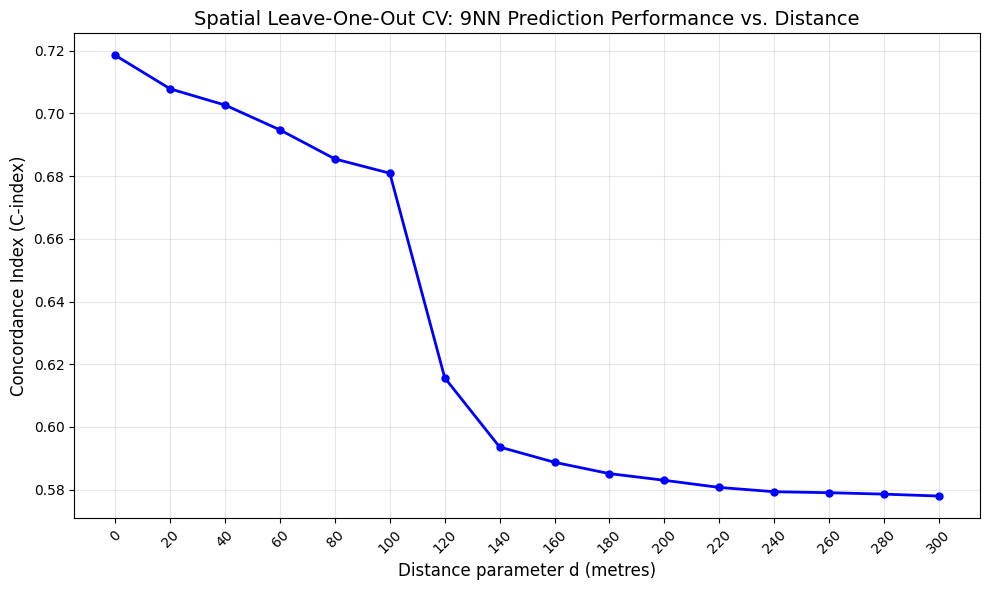

In [19]:
# Convert output to 1D numpy array
y_values = y.values.ravel()
coordinate_array = coords.values

# Compute pairwise distance matrix e(c_j, c_k) between all data points
dist_matrix = cdists(coordinate_array)

# D: full dataset indices
n = len(y_values)
D = np.arange(n)

# V: set of cross-validation folds (Leave-One-Out => K = n, each fold has 1 point)
# V_i = {i} for i = 0, ..., n-1
K = n

# A: learning algorithm (9-nearest neighbor regression)
A = lambda X_train, y_train: KNeighborsRegressor(n_neighbors=9).fit(X_train, y_train)

# Distance parameter values: r_delta = 0, 20, 40, ..., 300
r_delta_values = np.arange(0, 301, 20)

# Store C-index results for each distance parameter value
c_index_results = []

# --- Spatial leave-one-out cross-validation ---
# For each distance parameter r_delta, run SKCV

for r_delta in r_delta_values:
    y_hat = np.full(n, np.nan)  # predicted values for test samples

    # for i <- 1 to K iterate over each fold
    for i in range(K):
        V_i = [i]  # ith fold contains only data point i (leave-one-out)

        # H <- union over d_k in V_i of {d_j in D | e(c_j, c_k) <= r_delta}
        # Collect all data points d_j that are within distance r_delta from any point in V_i
        H = set()
        for k in V_i:
            for j in D:
                if dist_matrix[j, k] <= r_delta:
                    H.add(j)

        # F <- A(D \ H)  (build model using reduced training set)
        train_indices = np.array([j for j in D if j not in H])

        # Need at least 9 training points for 9NN
        if len(train_indices) >= 9:
            F = A(X_standardized[train_indices], y_values[train_indices])

            # for d_k in V_i do: y_hat[k] <- F(x_k)  (make prediction)
            for k in V_i:
                y_hat[k] = F.predict(X_standardized[k].reshape(1, -1))[0]

    # Calculate C-index from the predicted values
    valid_mask = ~np.isnan(y_hat)
    if valid_mask.sum() > 1:
        ci = cindex(y_values[valid_mask], y_hat[valid_mask])
    else:
        ci = np.nan

    c_index_results.append(ci)
    print(f"r_delta = {r_delta:3d} m | C-index = {ci:.4f} | Valid predictions: {valid_mask.sum()}/{n}")

# Visualize the results: C-index as a function of distance parameter r_delta
plt.figure(figsize=(10, 6))
plt.plot(r_delta_values, c_index_results, 'b-o', markersize=5, linewidth=2)
plt.xlabel('Distance parameter d (metres)', fontsize=12)
plt.ylabel('Concordance Index (C-index)', fontsize=12)
plt.title('Spatial Leave-One-Out CV: 9NN Prediction Performance vs. Distance', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(r_delta_values, rotation=45)
plt.tight_layout()
plt.show()

## Analysis of the results

### In this cell, you need to answer the client's questions:


1. **What happens to the 9NN performance as the prediction distance increases?**

As the prediction distance (d) increases, the C-index of the 9NN model decreases. At d=0 (standard leave-one-out cross-validation), the C-index is at its highest (0.7185). As d grows, more spatially close points are excluded from the training set, and the performance degrades, dropping gradually from 0.72 at d=0 to around 0.68 at d=100, then more sharply to less than 0.62 at d=120, and eventually leveling off around 0.58 for larger distances.


2. **Do you think the results behave as was somewhat expected? Do they make sense, why?**

Yes, the results behave as expected. Spatial data typically exhibits spatial autocorrelation, nearby points tend to have more similar values than distant points. When d=0, the model benefits from this autocorrelation because spatially close (and therefore informationally similar) training points are included, leading to optimistic performance estimates. As d increases and these nearby points are excluded, the model's performance drops because the remaining training data is less representative of the test point's local conditions. The steep drop between d=100 and d=120 suggests there is a strong spatial correlation structure at roughly that distance scale. This shows why standard cross-validation can overestimate model performance on spatial data it fails to account for spatial dependence.


3. **If we require that the 9NN must have at least C-index performance of 0.68, then up to what distance should we trust the 9NN predictions, based on the results?**

Based on the results, the C-index remains above 0.68 up to d=100 metres (C-index = 0.6809). At d=120 metres, it drops to 0.6157, which is below 0.68. Therefore, we should trust the 9NN predictions up to approximately **100 metres** distance.

## AI usage disclaimer
AI is used mostly for syntax and clearing out the outputs etc.
Moreover, I took help of AI in plotting.
